In [1]:
import os
import numpy as np
import glob as glob
import pandas as pd
from pathlib import Path
from scipy.io import loadmat
import matplotlib.pyplot as plt
import math
import seaborn as sns
import scipy
from scipy.optimize import minimize
from matplotlib.colors import Normalize
import matplotlib as mpl

# Load Data

In [2]:
BPN_new = pd.read_parquet(Path(r"C:\2_P9Project_allData\1_DataStructure\ball_predictions\data\BPN_df_preproc.parquet", engine = 'pyarrow'))
BPN_new = BPN_new[BPN_new['genotype'] == "BPN"]

In [3]:
P9LT_new = pd.read_parquet(Path(r"C:\2_P9Project_allData\1_DataStructure\ball_predictions\data\P9LT_df_preproc.parquet", engine = 'pyarrow'))
P9LT_new = P9LT_new[P9LT_new['genotype'] == "P9LT"]

In [4]:
P9RT_new = pd.read_parquet(Path(r"C:\2_P9Project_allData\1_DataStructure\ball_predictions\data\P9RT_df_preproc.parquet", engine = 'pyarrow'))
P9RT_new = P9RT_new[P9RT_new['genotype'] == "P9RT"]

# Functions

In [5]:
def get_TD_LO(df, Leg, idx_ts):
    """Extracts touchdown and liftoff frame indices from genotype dataframe using step cycle predictions

    Parameters
    ----------
    df : DataFrame
        Genotype dataframe with step cycle predictions
    Leg : string
        'L1'/'L2'/'L3' etc

    Returns
    -------
    DataFrame
        df with TD and LO time indices as columns or empty df if no TD or LO events detected
    """

    if Leg == "L1":
        SC = df["L-F_stepcycle"].astype(int)
    elif Leg == "L2":
        SC = df["L-M_stepcycle"].astype(int)
    elif Leg == "L3":
        SC = df["L-H_stepcycle"].astype(int)
    elif Leg == "R1":
        SC = df["R-F_stepcycle"].astype(int)
    elif Leg == "R2":
        SC = df["R-M_stepcycle"].astype(int)
    elif Leg == "R3":
        SC = df["R-H_stepcycle"].astype(int)

    Leg_diff = pd.DataFrame(np.diff(np.array(SC)))
    Leg_TD_frame = pd.DataFrame(Leg_diff.index[Leg_diff[0] == 1])
    Leg_LO_frame = pd.DataFrame(Leg_diff.index[Leg_diff[0] == -1])

    if (len(Leg_TD_frame) > 0) & (len(Leg_LO_frame) > 0):

        Leg_SC_init = pd.concat([Leg_TD_frame, Leg_LO_frame], axis=1)
        Leg_SC_init.columns = ["TD", "LO"]
        return Leg_SC_init + idx_ts
    else:
        # raise TypeError("INFO: No touchdown-liftoff pair detected in dataframe")
        Leg_SC_init = pd.DataFrame(columns = ['TD', 'LO'])
        return Leg_SC_init


In [6]:
# align arrays to get stance
def align_arr(SC_df):
    """Pairs up TD and LO events such that every TD is followd by a LO to form a complete stance event

    Parameters
    ----------
    SC_df : DataFrame
        Dataframe with TD and LO time indices

    Returns
    -------
    DataFrame
        Dataframe with paired TD-LO events, empty Df if input df was empty
    """
    if SC_df.empty:
        return pd.DataFrame(columns = ['TD, LO'])
    else:
        SC_df_new = pd.DataFrame()
        ## get first TD and LO events
        TD_1 = int(SC_df["TD"][0])
        LO_1 = int(SC_df["LO"][0])

        if LO_1 < TD_1:  # if the first event is a lift off
            # LO_new = SC_df.iloc[1:, 1].reset_index(drop=True)
            # SC_df_new = pd.concat([SC_df.iloc[:, 0], LO_new], axis=1).dropna()
            SC_df_new = pd.concat([SC_df["LO"], SC_df["TD"]], axis=1)
            # SC_df_new.columns = ["TD", "LO"]
        else:
            SC_df_new = SC_df

        return SC_df_new

In [7]:
def vel_filt_steps(aligned_SC, trialdf):
    """append mean velocities (RECTIFIED x and z) during the time window defined by the time indiced in the time_aligned SC dataframe.

    Parameters
    ----------
    aligned_SC : DataFrame
        time aligned step cycle df, event in first column preceeds the event in the 2nd column
    trialdf : DataFrame
        original dataframe with instentaneous velocities

    Returns
    -------
    DataFrame
        _description_
    """
    if aligned_SC.empty:
        return pd.DataFrame(columns = ['TD, LO', 'mean_xvel', 'mean_zvel'])
    else:
        
        event_1 = aligned_SC.columns.tolist()[0] 
        event_2 = aligned_SC.columns.tolist()[1]

        mean_x_vel = []
        mean_z_vel = []

        for step in range (len(aligned_SC.dropna())):

            temp_event1 = int(aligned_SC[event_1][step])
            temp_event2 = int(aligned_SC[event_2][step])
            
            ## TODO : add rectifiction as optional parameter
            mean_x_vel_step = np.mean(abs(trialdf['x_vel'])[temp_event1:temp_event2])
            mean_x_vel.append(mean_x_vel_step)

            mean_z_vel_step = np.mean(abs(trialdf['z_vel'])[temp_event1:temp_event2])
            mean_z_vel.append(mean_z_vel_step)     

        SC_withvel = pd.concat([aligned_SC, pd.DataFrame(mean_x_vel), pd.DataFrame(mean_z_vel)], axis = 1)
        SC_withvel.columns = [event_1, event_2, 'mean_xvel', 'mean_zvel']
        return SC_withvel

In [8]:
def get_walking_bouts (vel_filt_df, filter_by, thresh_min):
    """breaks stim duration into walking bouts based on x or z vel thresholds.
    TODO : add way to filter by x and z together
    TODO : add binning funcationality with optional maxthresh parameter

    Parameters
    ----------
    vel_filt_df : _type_
        _description_
    x_thresh_min : _type_
        _description_

    Returns
    -------
    _type_
        _description_
    """
    if vel_filt_df.empty:
        return pd.DataFrame(columns = [['WB'] + vel_filt_df.columns.tolist()])
    else:
        min = int(thresh_min)
        col = [x for x in vel_filt_df.columns.tolist() if filter_by in x][0]

        breakpts = np.array(vel_filt_df.index[(vel_filt_df[col]<min)].tolist())
        breakpts2 =np.split(breakpts, np.where(np.diff(breakpts) !=1)[0]+1) # indices in the TD-LO arry to split
        to_xclude = []

        if len(breakpts>0):
            for b in breakpts2:
                    start = b[0]
                    end = b[len(b)-1]
                    bout = [start, end]
                    to_xclude.append(bout)

            walking_bouts= pd.DataFrame()

            for n in range(len(to_xclude)+1):
                prev_bout = to_xclude[n-1] ## not used for n = 0

                if n== 0:
                    curr_bout = to_xclude[n]
                    curr_WB = vel_filt_df.iloc[0:curr_bout[0], :]

                elif 0<n<len(to_xclude):   
                    curr_bout = to_xclude[n]
                    curr_WB = vel_filt_df.iloc[prev_bout[1]+1:curr_bout[0], :]

                else:
                    curr_WB = vel_filt_df.iloc[curr_bout[1]+1:, :] 

                curr_WB_list = np.zeros(len(curr_WB))

                for i in range (len(curr_WB_list)):
                    curr_WB_list[i] = int(int(n)) 

                curr_WB = pd.concat([pd.DataFrame(curr_WB_list).reset_index(drop=True),
                                    curr_WB.reset_index(drop=True) ], axis = 1)
                
                walking_bouts = pd.concat([walking_bouts, curr_WB.reset_index(drop=True)], axis = 0)

            walking_bouts.columns = ['WB'] + vel_filt_df.columns.tolist()
            walking_bouts = walking_bouts.reset_index(drop=True)

        else:
            curr_WB_list = np.zeros(len(vel_filt_df))
            for i in range (len(curr_WB_list)):
                curr_WB_list[i] = 1
            walking_bouts = pd.concat([pd.DataFrame(curr_WB_list).reset_index(drop=True),vel_filt_df.reset_index(drop=True) ], axis = 1)
            walking_bouts.columns = ['WB'] + vel_filt_df.columns.tolist()
            walking_bouts = walking_bouts.reset_index(drop=True)

        return walking_bouts

In [9]:
def diff_row(df):
    diff_list = []
    for i in range(len(df)):
        temp_diff = np.diff(np.array(df.iloc[i]))
        diff_list.append(temp_diff[0])
    return pd.DataFrame(diff_list).reset_index(drop=True)


def diff_col(df):
    return pd.DataFrame(np.diff(np.array(df.iloc[:, 0]))).reset_index(drop=True)


def diff_next_step(df):
    diff_list = []
    for i in range(len(df) - 1):
        event1 = df.iloc[i, 1]
        event2 = df.iloc[i + 1, 0]
        temp_diff = event2 - event1
        diff_list.append(temp_diff.astype(float))
    return pd.DataFrame(diff_list).reset_index(drop=True)


In [10]:
def get_temp_params_WB(walking_bouts):    
    """Extracts temporal stepping parametrs (stance duration, swing duration, step period)
    using paired TD-LO indices

    Parameters
    ----------
    walking_bouts : DataFrame
        DF with walking bout indices, TD and LO timepoints

    Returns
    -------
    DataFrame
        Original dataframe with temporal parameter columns appended
    """
    if walking_bouts.empty:
        return pd.DataFrame()
    else:

        WB_df_temp_param = pd.DataFrame()

        for bout in walking_bouts['WB'].unique().tolist():
            temp_WB = walking_bouts.groupby('WB').get_group(bout)

            if temp_WB.columns[1] == "LO": ## first event is LO 
                temp_WB_arr = temp_WB[['LO', 'TD']]

                swing_dur = diff_row(temp_WB_arr)
                stance_dur = diff_next_step(temp_WB_arr)
                step_period = diff_col(temp_WB_arr)

            else: ## first event is TD
                temp_WB_arr = temp_WB[['TD', 'LO']]
                
                swing_dur = diff_next_step(temp_WB_arr)
                stance_dur = diff_row(temp_WB_arr)
                step_period = diff_col(temp_WB_arr)

            try:
                swing_dur.columns = ["swing_dur"]
            except:
                swing_dur = pd.DataFrame(columns=["swing_dur"])
            try:
                stance_dur.columns = ["stance_dur"]
            except:
                swing_dur = pd.DataFrame(columns=["stance_dur"])
            try:
                step_period.columns = ["step_period"]
            except:
                step_period = pd.DataFrame(columns=["step_period"])
            
            new_temp_WB = pd.concat([
                temp_WB.reset_index(drop=True), swing_dur, stance_dur, step_period
            ], axis = 1).reset_index(drop=True)


            WB_df_temp_param = pd.concat([WB_df_temp_param, new_temp_WB ], axis = 0).reset_index(drop=True)
        return WB_df_temp_param

In [11]:
def get_stance_dist_WB(WB_df_temp_param, data, leg, BL=1):
    """Quantifies and appends stance distance to input df

    Parameters
    ----------
    WB_df_temp_param : DataFrame
        Datafram with paired TD-LO columns
    data : DataFrame
        original dataframe with location coordinates
    leg : string
        'L1'/'L2'/'L3' etc
    BL : int, optional
        body length of individual fly calculated as the distance between the two wing hinges, by default 1

    Returns
    -------
    DataFrame
        appends normalized stance distance to the input datarame; returns empty if input was empty
    """
    R1_TaG_idx= [data.columns.get_loc('R-F-TaG_x'), data.columns.get_loc('R-F-TaG_y'), data.columns.get_loc('R-F-TaG_z')]
    R2_TaG_idx= [data.columns.get_loc('R-M-TaG_x'), data.columns.get_loc('R-M-TaG_y'), data.columns.get_loc('R-M-TaG_z')]
    R3_TaG_idx= [data.columns.get_loc('R-H-TaG_x'), data.columns.get_loc('R-H-TaG_y'), data.columns.get_loc('R-H-TaG_z')]

    L1_TaG_idx= [data.columns.get_loc('L-F-TaG_x'), data.columns.get_loc('L-F-TaG_y'), data.columns.get_loc('L-F-TaG_z')]
    L2_TaG_idx= [data.columns.get_loc('L-M-TaG_x'), data.columns.get_loc('L-M-TaG_y'), data.columns.get_loc('L-M-TaG_z')]
    L3_TaG_idx= [data.columns.get_loc('L-H-TaG_x'), data.columns.get_loc('L-H-TaG_y'), data.columns.get_loc('L-H-TaG_z')]

    if WB_df_temp_param.empty:
        return pd.DataFrame()
    
    else:
        if leg == "L1":
            Leg_TaG = data.iloc[:, L1_TaG_idx]
        if leg == "L2":
            Leg_TaG = data.iloc[:, L2_TaG_idx]
        if leg == "L3":
            Leg_TaG = data.iloc[:, L3_TaG_idx]
        if leg == "R1":
            Leg_TaG = data.iloc[:, R1_TaG_idx]
        if leg == "R2":
            Leg_TaG = data.iloc[:, R2_TaG_idx]
        if leg == "R3":
            Leg_TaG = data.iloc[:, R3_TaG_idx]

        stance_dist = []
        TD_coord = pd.DataFrame()
        LO_coord = pd.DataFrame()

        WB_data = WB_df_temp_param[['WB', 'LO', 'TD']]

        for bout in WB_data['WB'].unique().tolist():
            temp_WB = WB_data.groupby('WB').get_group(bout).reset_index(drop=True)   

            if temp_WB.columns[1] == "TD":  ## if first event is stance
                if len(temp_WB.dropna()) > 0: ##at least one full stance

                    for step in range(len((temp_WB).dropna())):

                        TD_pos_step = pd.DataFrame(
                            Leg_TaG.iloc[int(temp_WB["TD"][step]), :]
                        ).T
                        LO_pos_step = pd.DataFrame(
                            Leg_TaG.iloc[int(temp_WB["LO"][step]), :]
                        ).T
                        stance_dist_step = math.dist(
                            TD_pos_step.iloc[0, :], LO_pos_step.iloc[0, :]
                        )

                        stance_dist.append(stance_dist_step)
                        TD_coord = pd.concat([TD_coord, TD_pos_step], axis = 0)
                        LO_coord = pd.concat([LO_coord, LO_pos_step], axis = 0)

                else: ## if theere is no copmpleted stance
                    stance_dist.append(np.nan) # NaN for stance distance

                    TD_pos_step = pd.DataFrame([np.nan]*3).T
                    TD_pos_step.columns = Leg_TaG.columns.tolist()

                    LO_pos_step = pd.DataFrame([np.nan]*3).T
                    LO_pos_step.columns = Leg_TaG.columns.tolist()

                    TD_coord = pd.concat([TD_coord, TD_pos_step], axis = 0)
                    LO_coord = pd.concat([LO_coord, LO_pos_step], axis = 0)

            elif temp_WB.columns[1] == "LO":  ## if first event is swing
                if len((temp_WB).dropna()) > 1:  ## if there are at least 2 lift offs

                    for step in range(len((temp_WB.dropna())) - 1):
                            TD_pos_step = pd.DataFrame(
                                Leg_TaG.iloc[int(temp_WB["TD"][step]), :]
                            ).T
                            LO_pos_step = pd.DataFrame(
                                Leg_TaG.iloc[int(temp_WB["LO"][step + 1]), :]
                            ).T

                            stance_dist_step = math.dist(
                                TD_pos_step.iloc[0, :], LO_pos_step.iloc[0, :]
                            )
                            stance_dist.append(stance_dist_step)
                            TD_coord = pd.concat([TD_coord, TD_pos_step], axis = 0)
                            LO_coord = pd.concat([LO_coord, LO_pos_step], axis = 0)

                    ## for the last step which is not complete- only LO
                    stance_dist.append(np.nan) # NaN for stance distance

                    TD_pos_step = pd.DataFrame([np.nan]*3).T
                    TD_pos_step.columns = Leg_TaG.columns.tolist()

                    LO_pos_step = pd.DataFrame([np.nan]*3).T
                    LO_pos_step.columns =  Leg_TaG.columns.tolist()

                    TD_coord = pd.concat([TD_coord, TD_pos_step], axis = 0)
                    LO_coord = pd.concat([LO_coord, LO_pos_step], axis = 0)


                else:
                    stance_dist.append(np.nan) # NaN for stance distance

                    TD_pos_step = pd.DataFrame([np.nan]*3).T
                    TD_pos_step.columns = Leg_TaG.columns.tolist()

                    LO_pos_step = pd.DataFrame([np.nan]*3).T
                    LO_pos_step.columns = Leg_TaG.columns.tolist()

                    TD_coord = pd.concat([TD_coord, TD_pos_step], axis = 0)
                    LO_coord = pd.concat([LO_coord, LO_pos_step], axis = 0)

            else:
                raise TypeError("Unexpected input to function")


        stance_dist_norm = pd.DataFrame([elem / BL for elem in stance_dist])


        Leg_all_data = pd.concat([WB_df_temp_param, stance_dist_norm, TD_coord.reset_index(drop=True), LO_coord.reset_index(drop=True)], axis=1)
        
        Leg_all_data.columns = [leg +"_"+ x for x in WB_df_temp_param.columns.tolist() + ['stance_dist'] + ['TD_TaG_x', 'TD_TaG_y','TD_TaG_z','LO_TaG_x', 'LO_TaG_y', 'LO_TaG_z']]


        return Leg_all_data

In [12]:
def interleg_phase(df_leg1 , df_leg2):
    """returns a list of per step phase shift between two legs. 

    Parameters
    ----------
    df_leg1 : DataFrame
        _description_
    df_leg2 : DataFrame
        _description_

    Returns
    -------
    list
        _description_
    """
    if len(df_leg1) >0 and len (df_leg2)>0:
        series1 = df_leg1[[x for x in df_leg1.columns.tolist() if 'TD' in x][0]].dropna()
        series2 = df_leg2[[x for x in df_leg2.columns.tolist() if 'TD' in x][0]].dropna()
        
        if len(series1)>= len(series2):
            ref = series1
            test = series2
        else:
            ref = series2
            test = series1
        phase_arr = []
        for i in range(len(ref)-1):
            temp_ref1 = int(ref[i])
            temp_ref2 = int(ref[i+1])


            for l in range(len(test)):
                temp_test = int(test[l])
                if temp_ref1<=temp_test<=temp_ref2:
                    step = temp_ref2 - temp_ref1
                    offset = temp_ref2 - temp_test
                    temp_phase = offset/step
                    phase_arr.append(temp_phase)
        return  phase_arr
    else:
        return []

In [13]:
def magnitude(vector):
    return math.sqrt(sum(pow(element, 2) for element in vector))

def get_stepping_direction(df, leg_stepdata, leg):
    """adds a coilumn for step direction. appends NaN if a step has no stance distance associated

    Parameters
    ----------
    df : DataFrame
        Original dataframe with Notum and WH cooridinates
    leg_stepdata : DataFrae
        Dataframe with TD and LO coordinated for each step

    Returns
    -------
    Dataframe
        leg_stepdata df with 'step_dir' added
    """
    x_mid = (np.mean(df['L-WH_x']) +  np.mean(df['R-WH_x']))/2
    y_mid = (np.mean(df['L-WH_y']) +  np.mean(df['R-WH_y']))/2

    ref_WH = (x_mid, y_mid)

    Ref_vector =   np.mean(df['Notum_x'])- ref_WH[0] ,   np.mean(df['Notum_y'])-ref_WH[1]
   

    direction= []
    for i in range (len(leg_stepdata)):
        
        if pd.isnull(leg_stepdata[leg+ '_' + 'stance_dist'][i]) :

            direction.append(np.nan)

        else:
            
            step =(leg_stepdata[leg + '_' + 'LO_TaG_x'][i] - leg_stepdata[leg + '_' + 'TD_TaG_x'][i], 
                leg_stepdata[leg + '_' + 'LO_TaG_y'][i] - leg_stepdata[leg + '_' + 'TD_TaG_y'][i])
            
            angle = np.degrees(np.arccos((np.dot(Ref_vector,step ) / (magnitude(Ref_vector) * magnitude(step)))))
            
            direction.append (angle)

    direction = pd.DataFrame(direction)
    try:
        direction.columns = [leg+'_' + 'step_dir']
    except:
        direction = pd.DataFrame(columns= [leg+'_' + 'step_dir'])

    with_dir = pd.concat([leg_stepdata, direction], axis = 1)

    return with_dir

In [14]:
def all_data_genotype(genotype, filter_by, thresh):
    
    All_data_dict = {
        'L1' : pd.DataFrame(),
        'L2' : pd.DataFrame(),
        'L3' : pd.DataFrame(),
        'R1' : pd.DataFrame(),
        'R2' : pd.DataFrame(),
        'R3' : pd.DataFrame()
    }

    All_phase_dict = {
                'L1R1' : [],
                'L2R2': [],
                'L3R3': [],

                'L1L2': [],
                'R1R2': [],

                'L1L3': [],
                'R1R3': [],
                'L1R2': [],
                'R1L2': []
    }

    flies = genotype["flynum"].unique()
    for fly in flies:
        trial = genotype.groupby("flynum").get_group(fly)["tnum"].unique()
        for t in trial:

            print("INFO: Extracting data for ", (fly, t))

            data = (
                genotype.groupby("flynum")
                .get_group(fly)
                .groupby("tnum")
                .get_group(t)
                .reset_index(drop=True)
            )

            data_stim = data.iloc[400:1000]  
            idx_ts = data_stim.index[0] ## to maintain alignment with full dataframe

            # Defining body length as distance between wing hinges
            BL = math.dist(
                [
                    np.mean(data["R-WH_x"]),
                    np.mean(data["R-WH_y"]),
                    np.mean(data["R-WH_z"]),
                ],
                [
                    np.mean(data["L-WH_x"]),
                    np.mean(data["L-WH_y"]),
                    np.mean(data["L-WH_z"]),
                ],
            )

            L1_stepdata = get_stance_dist_WB(get_temp_params_WB(get_walking_bouts (vel_filt_steps(align_arr(get_TD_LO(data_stim, 'L1', idx_ts) ), data), filter_by, thresh)), data, 'L1', BL= BL)
            L1_stepdata.insert(0, 'tnum', t)
            L1_stepdata.insert(0, 'flynum', fly)

            L2_stepdata = get_stance_dist_WB(get_temp_params_WB(get_walking_bouts (vel_filt_steps(align_arr(get_TD_LO(data_stim, 'L2', idx_ts) ), data), filter_by, thresh)), data, 'L2', BL= BL)
            L2_stepdata.insert(0, 'tnum', t)
            L2_stepdata.insert(0, 'flynum', fly)

            L3_stepdata = get_stance_dist_WB(get_temp_params_WB(get_walking_bouts (vel_filt_steps(align_arr(get_TD_LO(data_stim, 'L3', idx_ts) ), data), filter_by, thresh)), data, 'L3', BL= BL)
            L3_stepdata.insert(0, 'tnum', t)
            L3_stepdata.insert(0, 'flynum', fly)

            R1_stepdata = get_stance_dist_WB(get_temp_params_WB(get_walking_bouts (vel_filt_steps(align_arr(get_TD_LO(data_stim, 'R1', idx_ts) ), data), filter_by, thresh)), data, 'R1', BL= BL)
            R1_stepdata.insert(0, 'tnum', t)
            R1_stepdata.insert(0, 'flynum', fly)

            R2_stepdata = get_stance_dist_WB(get_temp_params_WB(get_walking_bouts (vel_filt_steps(align_arr(get_TD_LO(data_stim, 'R2', idx_ts) ), data), filter_by, thresh)), data, 'R2', BL= BL)
            R2_stepdata.insert(0, 'tnum', t)
            R2_stepdata.insert(0, 'flynum', fly)

            R3_stepdata = get_stance_dist_WB(get_temp_params_WB(get_walking_bouts (vel_filt_steps(align_arr(get_TD_LO(data_stim, 'R3', idx_ts) ), data), filter_by, thresh)), data, 'R3', BL= BL)
            R3_stepdata.insert(0, 'tnum', t)
            R3_stepdata.insert(0, 'flynum', fly)

            L1_with_dir = get_stepping_direction(data, L1_stepdata, 'L1')
            L2_with_dir = get_stepping_direction(data, L2_stepdata, 'L2')
            L3_with_dir = get_stepping_direction(data, L3_stepdata, 'L3')
            R1_with_dir = get_stepping_direction(data, R1_stepdata, 'R1')
            R2_with_dir = get_stepping_direction(data, R2_stepdata, 'R2')
            R3_with_dir = get_stepping_direction(data, R3_stepdata, 'R3')
            
            for leg, datast_temp in zip(['L1', 'L2', 'L3', 'R1', 'R2', 'R3'], [L1_with_dir, L2_with_dir, L3_with_dir, R1_with_dir, R2_with_dir, R3_with_dir]):
                All_data_dict[leg] = pd.concat([ All_data_dict[leg], datast_temp], axis = 0).reset_index(drop=True)
            
            All_phase_dict['L1R1'].extend(interleg_phase(L1_stepdata, R1_stepdata))
            All_phase_dict['L2R2'].extend(interleg_phase(L2_stepdata, R2_stepdata))
            All_phase_dict['L3R3'].extend(interleg_phase(L3_stepdata, R3_stepdata))

            All_phase_dict['L1L2'].extend(interleg_phase(L1_stepdata, R1_stepdata))
            All_phase_dict['R1R2'].extend(interleg_phase(R1_stepdata, R2_stepdata))

            All_phase_dict['L1L3'].extend(interleg_phase(L1_stepdata, L3_stepdata))
            All_phase_dict['R1R3'].extend(interleg_phase(R1_stepdata, R3_stepdata))
            All_phase_dict['L1R2'].extend(interleg_phase(L1_stepdata, R2_stepdata))
            All_phase_dict['R1L2'].extend(interleg_phase(R1_stepdata, L2_stepdata))

            
    return All_data_dict, All_phase_dict


## Plotting Functions

In [15]:
def plot_barplots (All_data_dict):

    fig, ax = plt.subplots(1,4, figsize = (12,7) )
    
    ax[0].boxplot([All_data_dict['L1']['L1_swing_dur'].dropna(),
                All_data_dict['R1']['R1_swing_dur'].dropna(),
                All_data_dict['L2']['L2_swing_dur'].dropna(),
                All_data_dict['R2']['R2_swing_dur'].dropna(),
                All_data_dict['L3']['L3_swing_dur'].dropna(),
                All_data_dict['R3']['R3_swing_dur'].dropna()], labels = ['L1', 'R1', 'L2', 'R2', 'L3', 'R3'])
    ax[0].title.set_text("Swing Dur")

    ax[1].boxplot([All_data_dict['L1']['L1_stance_dur'].dropna(),
                All_data_dict['R1']['R1_stance_dur'].dropna(),
                All_data_dict['L2']['L2_stance_dur'].dropna(),
                All_data_dict['R2']['R2_stance_dur'].dropna(),
                All_data_dict['L3']['L3_stance_dur'].dropna(),
                All_data_dict['R3']['R3_stance_dur'].dropna()],labels = ['L1', 'R1', 'L2', 'R2', 'L3', 'R3'])
    ax[1].title.set_text("Stance Dur")

    ax[2].boxplot([All_data_dict['L1']['L1_stance_dist'].dropna(),
                All_data_dict['R1']['R1_stance_dist'].dropna(),
                All_data_dict['L2']['L2_stance_dist'].dropna(),
                All_data_dict['R2']['R2_stance_dist'].dropna(),
                All_data_dict['L3']['L3_stance_dist'].dropna(),
                All_data_dict['R3']['R3_stance_dist'].dropna()], labels = ['L1', 'R1', 'L2', 'R2', 'L3', 'R3'])
    ax[2].title.set_text("Stance Dist")

    ax[3].boxplot([All_data_dict['L1']['L1_step_dir'].dropna(),
                All_data_dict['R1']['R1_step_dir'].dropna(),
                All_data_dict['L2']['L2_step_dir'].dropna(),
                All_data_dict['R2']['R2_step_dir'].dropna(),
                All_data_dict['L3']['L3_step_dir'].dropna(),
                All_data_dict['R3']['R3_step_dir'].dropna()], labels = ['L1', 'R1', 'L2', 'R2', 'L3', 'R3'])
    ax[3].title.set_text("Stance Direction")

    plt.tight_layout()
    plt.show()


In [16]:
def phase_plot(phase_dict):
    color_list = ['salmon', 'peru', 'darkorange',
            'olive', 'deepskyblue',
            'forestgreen', 'violet',
            'olive', 'deepskyblue']
    name_list=  phase_dict.keys()

    i = 0
    fig, ax = plt.subplots(1, 9, subplot_kw=dict(polar=True), figsize = (20,10))

    for pair, color, name in zip(phase_dict.keys(), color_list, name_list):
        
        temp = [x*2*np.pi for x in phase_dict[pair]]
        r, theta = np.histogram(temp, bins= 10, density = False)
        bars = ax[i].bar(theta[:-1], r, alpha = 0.5, label = name, color = color)
        ax[i].title.set_text(pair)

        i+=1
    for i in range(9):
        ax[i].spines['polar'].set_visible(False)  # Hide the polar axis line
        ax[i].set_theta_direction(-1)  # Clockwise direction for bars
        ax[i].set_theta_offset(np.pi / 2)  # Offset to start the bars from the top
        ax[i].set_yticks([])  # Hide the y-axis ticks
        
    plt.tight_layout()
    plt.show()

In [17]:
def get_stance_traj_plot(All_data_dict, title, path = None):
    """_summary_

    Parameters
    ----------
    All_data_dict : _type_
        _description_
    title : _type_
        _description_
    path : _type_, optional
        _description_, by default None
    """
    fig = plt.figure(figsize = (10,8))
    ax = fig.add_subplot(projection="3d")
    ax.title.set_text(title)
    ax.view_init(90,0)

    L1_data = All_data_dict['L1'][['L1_TD_TaG_x',	'L1_TD_TaG_y',	'L1_TD_TaG_z',	'L1_LO_TaG_x',	'L1_LO_TaG_y',	'L1_LO_TaG_z']]
    L2_data = All_data_dict['L2'][['L2_TD_TaG_x',	'L2_TD_TaG_y',	'L2_TD_TaG_z',	'L2_LO_TaG_x',	'L2_LO_TaG_y',	'L2_LO_TaG_z']]
    L3_data = All_data_dict['L3'][['L3_TD_TaG_x',	'L3_TD_TaG_y',	'L3_TD_TaG_z',	'L3_LO_TaG_x',	'L3_LO_TaG_y',	'L3_LO_TaG_z']]
    R1_data = All_data_dict['R1'][['R1_TD_TaG_x',	'R1_TD_TaG_y',	'R1_TD_TaG_z',	'R1_LO_TaG_x',	'R1_LO_TaG_y',	'R1_LO_TaG_z']]
    R2_data = All_data_dict['R2'][['R2_TD_TaG_x',	'R2_TD_TaG_y',	'R2_TD_TaG_z',	'R2_LO_TaG_x',	'R2_LO_TaG_y',	'R2_LO_TaG_z']]
    R3_data = All_data_dict['R3'][['R3_TD_TaG_x',	'R3_TD_TaG_y',	'R3_TD_TaG_z',	'R3_LO_TaG_x',	'R3_LO_TaG_y',	'R3_LO_TaG_z']]

    print(len(L1_data), len(L2_data), len(L3_data), len(R1_data), len(R2_data), len(R3_data))
    
    min_len = min(len(L1_data), len(L2_data), len(L3_data), len(R1_data), len(R2_data), len(R3_data))
    if min_len > 200:
        pts= 200
    else:
        pts = min_len
    for i in range (pts):
        x, y, z = [L1_data['L1_TD_TaG_x'][i], L1_data['L1_LO_TaG_x'][i]], [L1_data['L1_TD_TaG_y'][i], L1_data['L1_LO_TaG_y'][i]], [L1_data['L1_TD_TaG_z'][i], L1_data['L1_LO_TaG_z'][i]]
        ax.plot(x, y, z, color = 'peru' ,alpha = 0.2, linewidth=1.5)
        ax.plot3D(L1_data['L1_TD_TaG_x'][i],L1_data['L1_TD_TaG_y'][i],L1_data['L1_TD_TaG_z'][i], '.', color = 'darkorange')
        
    for i in range (pts):
        x, y, z = [R1_data['R1_TD_TaG_x'][i], R1_data['R1_LO_TaG_x'][i]], [R1_data['R1_TD_TaG_y'][i], R1_data['R1_LO_TaG_y'][i]], [R1_data['R1_TD_TaG_z'][i], R1_data['R1_LO_TaG_z'][i]]
        ax.plot(x, y, z, color = 'orangered' ,alpha = 0.2, linewidth=1.5)
        ax.plot3D(R1_data['R1_TD_TaG_x'][i],R1_data['R1_TD_TaG_y'][i],R1_data['R1_TD_TaG_z'][i], '.', color = 'orangered')

    for i in range (pts):
        x, y, z = [L2_data['L2_TD_TaG_x'][i], L2_data['L2_LO_TaG_x'][i]], [L2_data['L2_TD_TaG_y'][i], L2_data['L2_LO_TaG_y'][i]], [L2_data['L2_TD_TaG_z'][i], L2_data['L2_LO_TaG_z'][i]]
        ax.plot(x, y, z, color = 'darkslategrey' ,alpha = 0.2, linewidth=1.5)
        ax.plot3D(L2_data['L2_TD_TaG_x'][i],L2_data['L2_TD_TaG_y'][i],L2_data['L2_TD_TaG_z'][i], '.', color = 'darkslategrey')

    for i in range (pts):
        x, y, z = [R2_data['R2_TD_TaG_x'][i], R2_data['R2_LO_TaG_x'][i]], [R2_data['R2_TD_TaG_y'][i], R2_data['R2_LO_TaG_y'][i]], [R2_data['R2_TD_TaG_z'][i], R2_data['R2_LO_TaG_z'][i]]
        ax.plot(x, y, z, color = 'olive' ,alpha = 0.2, linewidth=1.5)
        ax.plot3D(R2_data['R2_TD_TaG_x'][i],R2_data['R2_TD_TaG_y'][i],R2_data['R2_TD_TaG_z'][i], '.', color = 'forestgreen')

    for i in range (pts):
        x, y, z = [L3_data['L3_TD_TaG_x'][i], L3_data['L3_LO_TaG_x'][i]], [L3_data['L3_TD_TaG_y'][i], L3_data['L3_LO_TaG_y'][i]], [L3_data['L3_TD_TaG_z'][i], L3_data['L3_LO_TaG_z'][i]]
        ax.plot(x, y, z, color = 'darkmagenta' ,alpha = 0.2, linewidth=1.5)
        ax.plot3D(L3_data['L3_TD_TaG_x'][i],L3_data['L3_TD_TaG_y'][i],L3_data['L3_TD_TaG_z'][i], '.', color = 'darkmagenta')

    for i in range (pts):
        x, y, z = [R3_data['R3_TD_TaG_x'][i], R3_data['R3_LO_TaG_x'][i]], [R3_data['R3_TD_TaG_y'][i], R3_data['R3_LO_TaG_y'][i]], [R3_data['R3_TD_TaG_z'][i], R3_data['R3_LO_TaG_z'][i]]
        ax.plot(x, y, z, color = 'royalblue' ,alpha = 0.2, linewidth=1.5)
        ax.plot3D(R3_data['R3_TD_TaG_x'][i],R3_data['R3_TD_TaG_y'][i],R3_data['R3_TD_TaG_z'][i], '.', color = 'royalblue')
    if path:
        plt.savefig(path, dpi = 300)

# Extract Data

In [18]:
All_data_dict_BPN, All_phase_dict_BPN = all_data_genotype(BPN_new, 'x', 5)

INFO: Extracting data for  (1, 1)
INFO: Extracting data for  (1, 2)
INFO: Extracting data for  (1, 3)
INFO: Extracting data for  (1, 4)
INFO: Extracting data for  (1, 5)
INFO: Extracting data for  (1, 6)
INFO: Extracting data for  (1, 7)
INFO: Extracting data for  (1, 8)
INFO: Extracting data for  (1, 9)
INFO: Extracting data for  (1, 10)
INFO: Extracting data for  (2, 1)
INFO: Extracting data for  (2, 2)
INFO: Extracting data for  (2, 3)
INFO: Extracting data for  (2, 4)
INFO: Extracting data for  (2, 5)
INFO: Extracting data for  (2, 6)
INFO: Extracting data for  (2, 7)
INFO: Extracting data for  (2, 8)
INFO: Extracting data for  (2, 9)
INFO: Extracting data for  (2, 10)
INFO: Extracting data for  (3, 1)
INFO: Extracting data for  (3, 2)
INFO: Extracting data for  (3, 3)
INFO: Extracting data for  (3, 4)
INFO: Extracting data for  (3, 5)
INFO: Extracting data for  (3, 6)
INFO: Extracting data for  (3, 7)
INFO: Extracting data for  (3, 8)
INFO: Extracting data for  (3, 9)
INFO: Extrac

In [19]:
All_data_dict_P9LT, All_phase_dict_P9LT = all_data_genotype(P9LT_new, 'z', 3)

INFO: Extracting data for  (1, 1)
INFO: Extracting data for  (1, 2)
INFO: Extracting data for  (1, 3)
INFO: Extracting data for  (1, 4)
INFO: Extracting data for  (1, 5)
INFO: Extracting data for  (1, 6)
INFO: Extracting data for  (1, 7)
INFO: Extracting data for  (1, 8)
INFO: Extracting data for  (1, 9)
INFO: Extracting data for  (1, 10)
INFO: Extracting data for  (2, 1)
INFO: Extracting data for  (2, 2)
INFO: Extracting data for  (2, 3)
INFO: Extracting data for  (2, 4)
INFO: Extracting data for  (2, 5)
INFO: Extracting data for  (2, 6)
INFO: Extracting data for  (2, 7)
INFO: Extracting data for  (2, 8)
INFO: Extracting data for  (2, 9)
INFO: Extracting data for  (2, 10)
INFO: Extracting data for  (3, 1)
INFO: Extracting data for  (3, 2)
INFO: Extracting data for  (3, 3)
INFO: Extracting data for  (3, 4)
INFO: Extracting data for  (3, 5)
INFO: Extracting data for  (3, 6)
INFO: Extracting data for  (3, 7)
INFO: Extracting data for  (3, 8)
INFO: Extracting data for  (3, 9)
INFO: Extrac

In [20]:
All_data_dict_P9RT, All_phase_dict_P9RT = all_data_genotype(P9RT_new, 'z', 3)

INFO: Extracting data for  (1, 1)
INFO: Extracting data for  (1, 2)
INFO: Extracting data for  (1, 3)
INFO: Extracting data for  (1, 4)
INFO: Extracting data for  (1, 5)
INFO: Extracting data for  (1, 6)
INFO: Extracting data for  (1, 7)
INFO: Extracting data for  (1, 8)
INFO: Extracting data for  (1, 9)
INFO: Extracting data for  (1, 10)
INFO: Extracting data for  (2, 1)
INFO: Extracting data for  (2, 2)
INFO: Extracting data for  (2, 3)
INFO: Extracting data for  (2, 4)
INFO: Extracting data for  (2, 5)
INFO: Extracting data for  (2, 6)
INFO: Extracting data for  (2, 7)
INFO: Extracting data for  (2, 8)
INFO: Extracting data for  (2, 9)
INFO: Extracting data for  (2, 10)
INFO: Extracting data for  (3, 1)
INFO: Extracting data for  (3, 2)
INFO: Extracting data for  (3, 3)
INFO: Extracting data for  (3, 4)
INFO: Extracting data for  (3, 5)
INFO: Extracting data for  (3, 6)
INFO: Extracting data for  (3, 7)
INFO: Extracting data for  (3, 8)
INFO: Extracting data for  (3, 9)
INFO: Extrac

# Plot Data

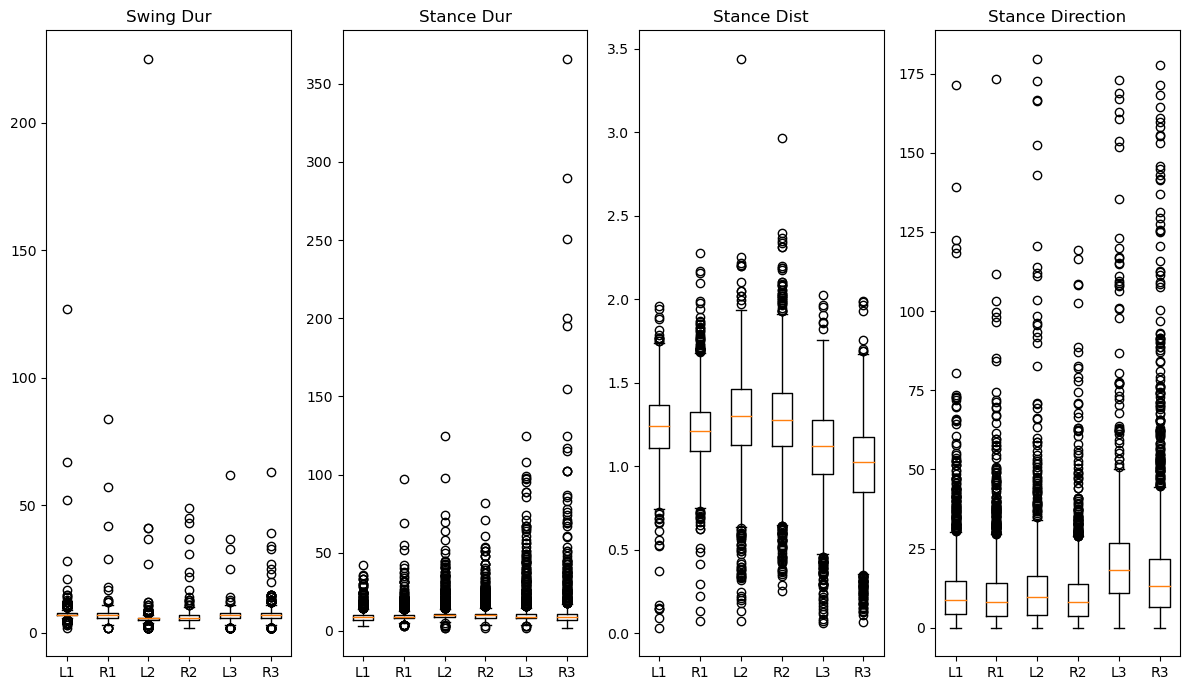

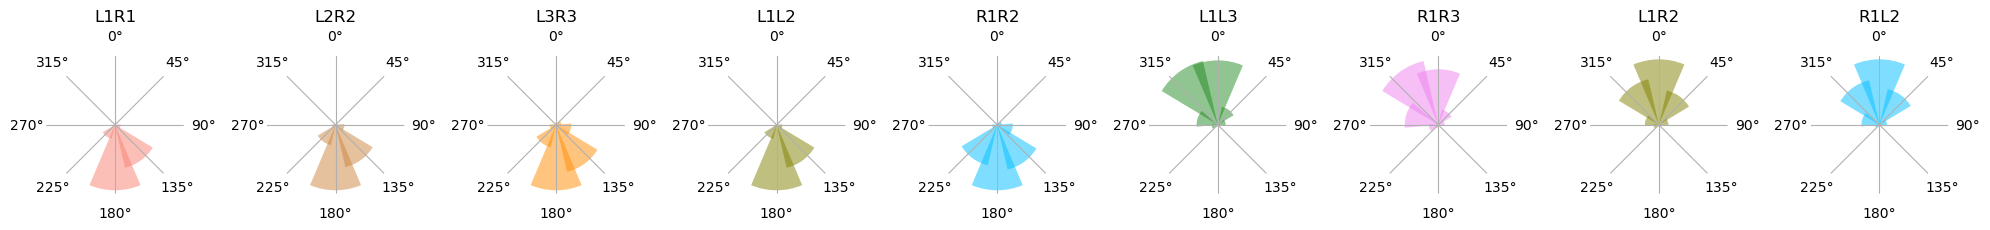

2796 2688 2620 2758 2728 2592


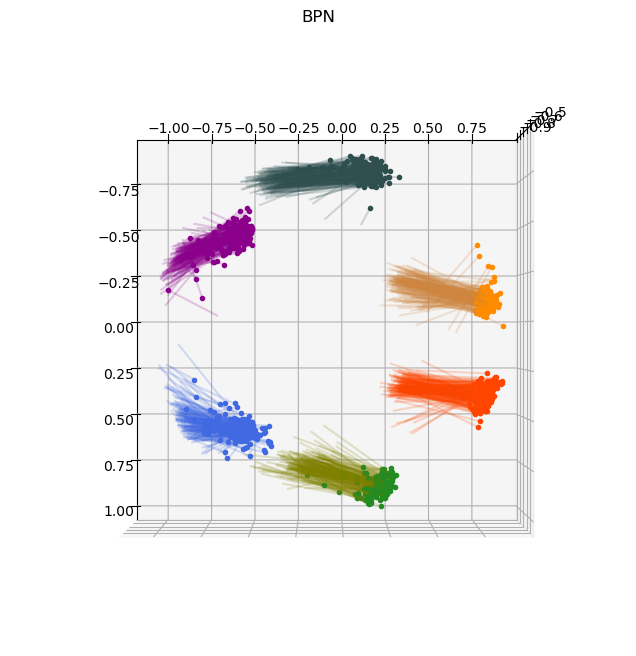

In [21]:
plot_barplots (All_data_dict_BPN)
plt.show()
phase_plot(All_phase_dict_BPN)
plt.show()
get_stance_traj_plot(All_data_dict_BPN, 'BPN', path = None)
plt.show()

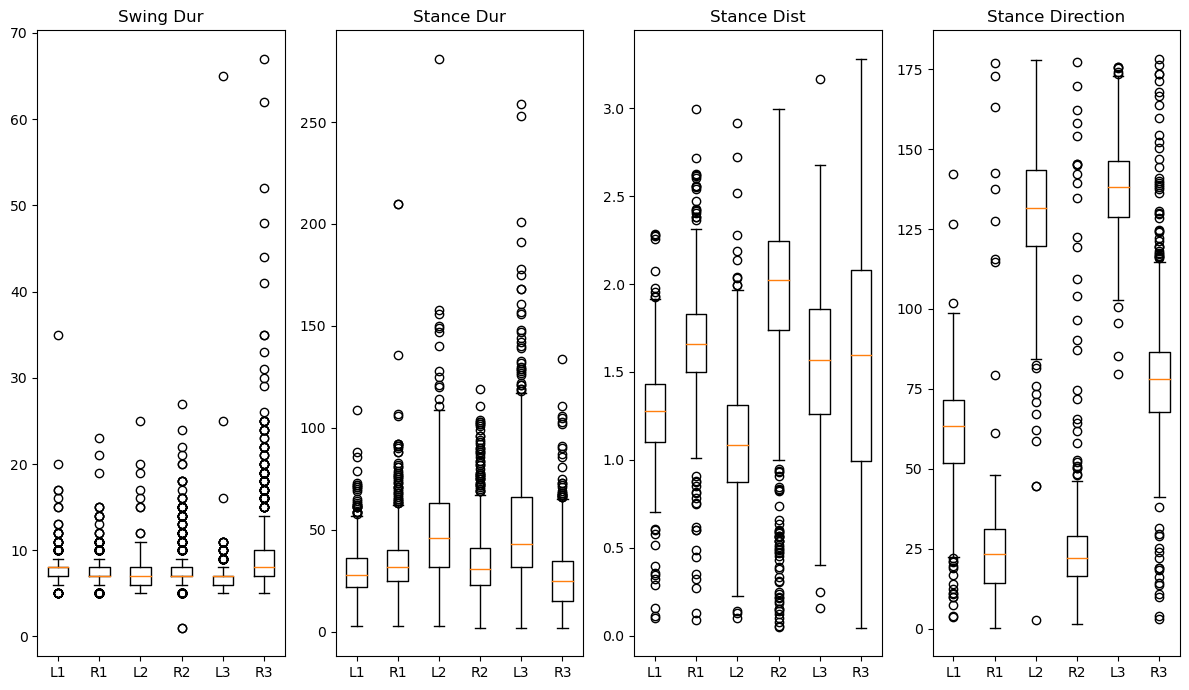

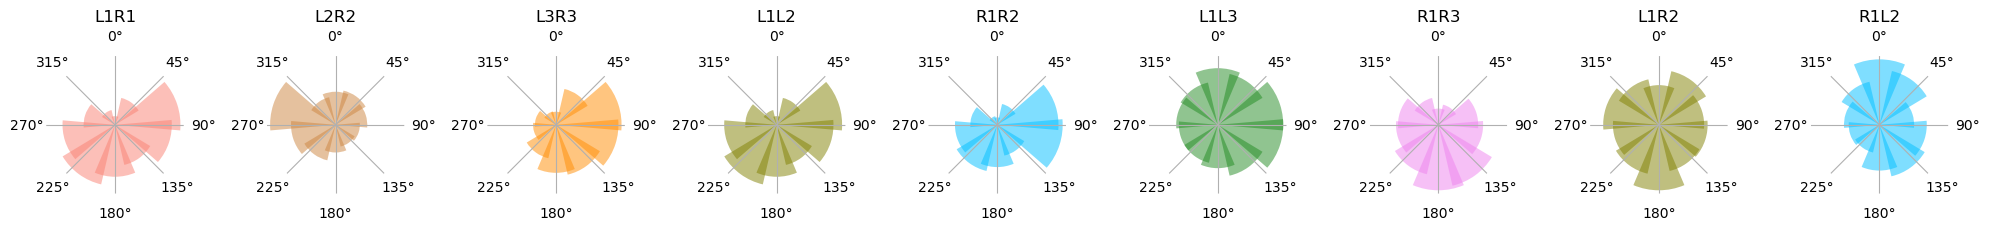

924 636 702 1000 962 1133


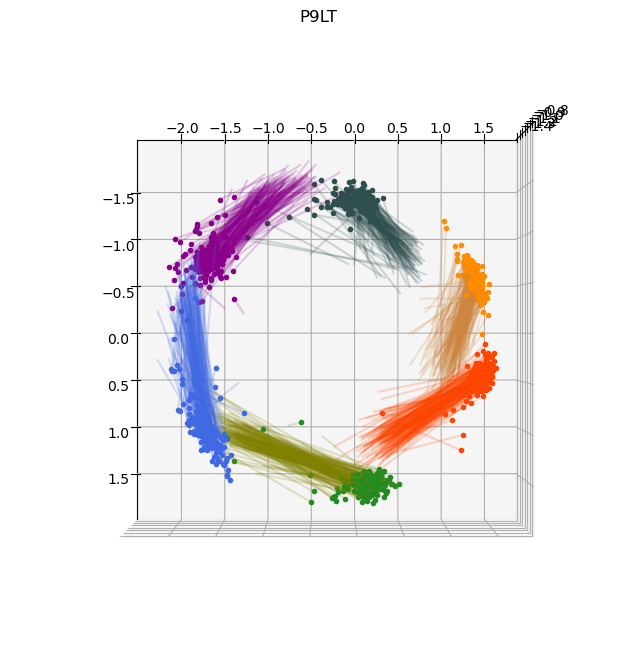

In [22]:
plot_barplots (All_data_dict_P9LT)
plt.show()
phase_plot(All_phase_dict_P9LT)
plt.show()
get_stance_traj_plot(All_data_dict_P9LT, 'P9LT', path = None)
plt.show()

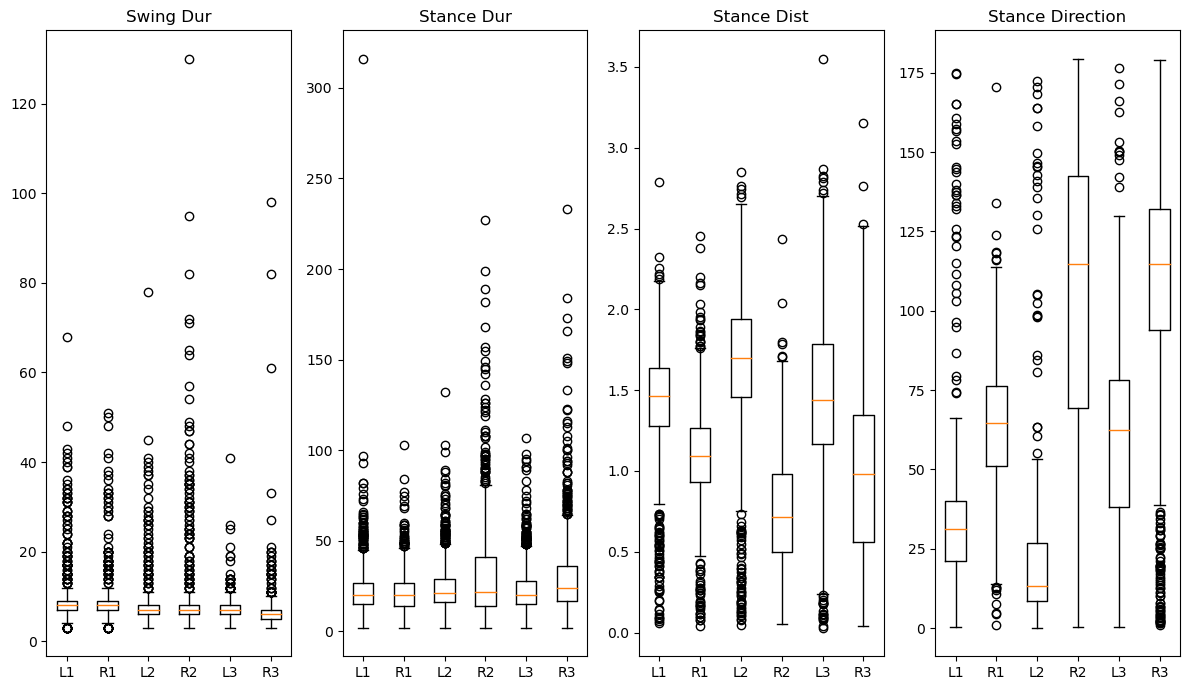

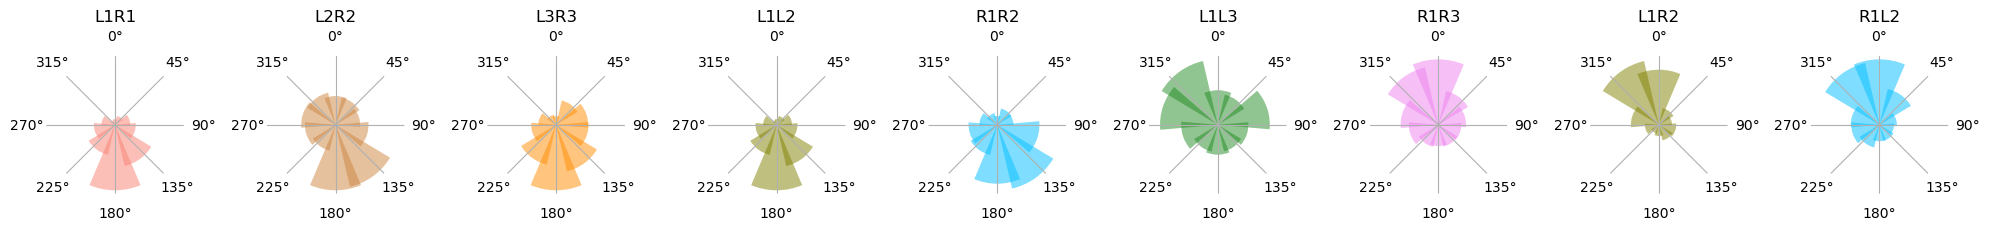

1409 1331 1348 1325 935 1175


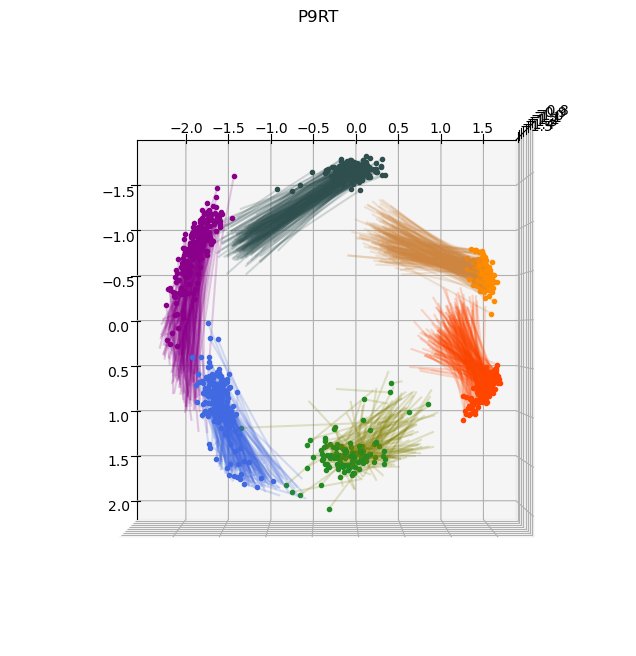

In [23]:
plot_barplots (All_data_dict_P9RT)
plt.show()
phase_plot(All_phase_dict_P9RT)
plt.show()
get_stance_traj_plot(All_data_dict_P9RT, 'P9RT', path = None)
plt.show()

# Troublehsoot

In [284]:
## groupby flies and trials
#get individual trial 
data = BPN_new.loc[(BPN_new['flynum'] == 1) & (BPN_new['tnum'] == 1)].reset_index(drop=True)
data_stim = data.iloc[400:1000, :]
idx_ts = data_stim.index[0] ## to maintain alignment with full dataframe

In [285]:
Leg_SC_init = get_TD_LO(data_stim, 'L1', idx_ts) ## get TD and LO events (not aligned)
Leg_SC_init

,TD,LO
0,427,422
1,447,441
2,462,455
3,478,473
4,497,490
5,514,508
6,530,524
7,548,543
8,565,559
9,583,576


In [286]:
SC_df_new = align_arr(Leg_SC_init) # aligns eevents such that each row represents a TD-LO or LO-TD pair
SC_df_new

,LO,TD
0,422,427
1,441,447
2,455,462
3,473,478
4,490,497
5,508,514
6,524,530
7,543,548
8,559,565
9,576,583


In [287]:
SC_withvel = vel_filt_steps(SC_df_new, data)
SC_withvel

,LO,TD,mean_xvel,mean_zvel
0,422,427,3.821092,0.673746
1,441,447,1.756983,7.396219
2,455,462,9.117408,9.839422
3,473,478,14.052498,5.947805
4,490,497,16.670148,1.741475
5,508,514,19.741113,0.101692
6,524,530,12.218636,1.858562
7,543,548,13.514269,1.582568
8,559,565,17.833615,1.500493
9,576,583,21.393027,1.681397


In [289]:
walking_bouts = get_walking_bouts (SC_withvel, 'x', 15)
walking_bouts

,WB,LO,TD,mean_xvel,mean_zvel
0,1.0,490,497,16.670148,1.741475
1,1.0,508,514,19.741113,0.101692
2,2.0,559,565,17.833615,1.500493
3,2.0,576,583,21.393027,1.681397
4,3.0,607,615,21.659018,2.564442
5,3.0,624,631,19.373346,3.181845
6,3.0,640,646,16.977498,3.286166
7,3.0,657,663,17.179159,3.171642
8,3.0,673,680,19.888777,3.555871
9,3.0,692,700,17.704104,2.273518


In [290]:
WB_df_temp_param = get_temp_params_WB(walking_bouts)
WB_df_temp_param

,WB,LO,TD,mean_xvel,mean_zvel,swing_dur,stance_dur,step_period
0,1.0,490,497,16.670148,1.741475,7.0,11.0,18.0
1,1.0,508,514,19.741113,0.101692,6.0,NaN,NaN
2,2.0,559,565,17.833615,1.500493,6.0,11.0,17.0
3,2.0,576,583,21.393027,1.681397,7.0,NaN,NaN
4,3.0,607,615,21.659018,2.564442,8.0,9.0,17.0
5,3.0,624,631,19.373346,3.181845,7.0,9.0,16.0
6,3.0,640,646,16.977498,3.286166,6.0,11.0,17.0
7,3.0,657,663,17.179159,3.171642,6.0,10.0,16.0
8,3.0,673,680,19.888777,3.555871,7.0,12.0,19.0
9,3.0,692,700,17.704104,2.273518,8.0,9.0,17.0


In [291]:
Leg_all_data = get_stance_dist_WB(WB_df_temp_param, data, 'L1', BL=1)
Leg_all_data

,L1_WB,L1_LO,L1_TD,L1_mean_xvel,L1_mean_zvel,L1_swing_dur,L1_stance_dur,L1_step_period,L1_stance_dist,L1_TD_TaG_x,L1_TD_TaG_y,L1_TD_TaG_z,L1_LO_TaG_x,L1_LO_TaG_y,L1_LO_TaG_z
0,1.0,490,497,16.670148,1.741475,7.0,11.0,18.0,0.517703,-0.078341,0.807806,-0.505011,-0.163169,0.302675,-0.429758
1,1.0,508,514,19.741113,0.101692,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,559,565,17.833615,1.500493,6.0,11.0,17.0,0.495550,-0.086825,0.800452,-0.480700,-0.256392,0.335637,-0.453071
3,2.0,576,583,21.393027,1.681397,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3.0,607,615,21.659018,2.564442,8.0,9.0,17.0,0.497552,-0.091231,0.781133,-0.521816,-0.211235,0.306121,-0.435098
5,3.0,624,631,19.373346,3.181845,7.0,9.0,16.0,0.484693,-0.083962,0.760366,-0.510146,-0.221499,0.300468,-0.443029
6,3.0,640,646,16.977498,3.286166,6.0,11.0,17.0,0.539588,-0.053184,0.803611,-0.488087,-0.201131,0.288695,-0.423833
7,3.0,657,663,17.179159,3.171642,6.0,10.0,16.0,0.550409,-0.108732,0.813750,-0.486166,-0.158425,0.268905,-0.425967
8,3.0,673,680,19.888777,3.555871,7.0,12.0,19.0,0.594780,-0.092382,0.819926,-0.513247,-0.191592,0.238708,-0.435099
9,3.0,692,700,17.704104,2.273518,8.0,9.0,17.0,0.482907,-0.140716,0.778449,-0.519468,-0.217784,0.312272,-0.419773


In [292]:
L1_stepdata = get_stance_dist_WB(get_temp_params_WB(get_walking_bouts (vel_filt_steps(align_arr(get_TD_LO(data_stim, 'L1', idx_ts) ), data), 'x', 15)), data, 'L1', BL=1)
L2_stepdata = get_stance_dist_WB(get_temp_params_WB(get_walking_bouts (vel_filt_steps(align_arr(get_TD_LO(data_stim, 'L2', idx_ts) ), data), 'x', 15)), data, 'L2', BL=1)
L3_stepdata = get_stance_dist_WB(get_temp_params_WB(get_walking_bouts (vel_filt_steps(align_arr(get_TD_LO(data_stim, 'L3', idx_ts) ), data), 'x', 15)), data, 'L3', BL=1)
R1_stepdata = get_stance_dist_WB(get_temp_params_WB(get_walking_bouts (vel_filt_steps(align_arr(get_TD_LO(data_stim, 'R1', idx_ts) ), data), 'x', 15)), data, 'R1', BL=1)
R2_stepdata = get_stance_dist_WB(get_temp_params_WB(get_walking_bouts (vel_filt_steps(align_arr(get_TD_LO(data_stim, 'R2', idx_ts) ), data), 'x', 15)), data, 'R2', BL=1)
R3_stepdata = get_stance_dist_WB(get_temp_params_WB(get_walking_bouts (vel_filt_steps(align_arr(get_TD_LO(data_stim, 'R3', idx_ts) ), data), 'x', 15)), data, 'R3', BL=1)

In [293]:
R1_stepdata

,R1_WB,R1_LO,R1_TD,R1_mean_xvel,R1_mean_zvel,R1_swing_dur,R1_stance_dur,R1_step_period,R1_stance_dist,R1_TD_TaG_x,R1_TD_TaG_y,R1_TD_TaG_z,R1_LO_TaG_x,R1_LO_TaG_y,R1_LO_TaG_z
0,1.0,482,488.0,15.796883,3.439613,6.0,11.0,17.0,0.560262,0.414930,0.796486,-0.562865,0.348794,0.254811,-0.435949
1,1.0,499,506.0,18.875905,0.365966,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,551,557.0,18.629189,1.557076,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.0,584,590.0,19.977495,1.741237,6.0,10.0,16.0,0.439185,0.403298,0.720389,-0.531903,0.261537,0.317331,-0.430259
4,3.0,600,606.0,19.939807,2.411279,6.0,10.0,16.0,0.504730,0.423541,0.716388,-0.521004,0.269101,0.248054,-0.413469
5,3.0,616,622.0,18.680710,2.937510,6.0,10.0,16.0,0.505619,0.361597,0.760746,-0.538976,0.252197,0.280894,-0.423116
6,3.0,632,639.0,19.365346,3.312223,7.0,10.0,17.0,0.468799,0.425880,0.753372,-0.520601,0.272198,0.318367,-0.437387
7,3.0,649,656.0,18.201093,3.167706,7.0,9.0,16.0,0.441035,0.468916,0.745585,-0.555544,0.297717,0.354207,-0.445882
8,3.0,665,671.0,22.135934,3.418268,6.0,12.0,18.0,0.511442,0.369812,0.733846,-0.504192,0.211305,0.253471,-0.428774
9,3.0,683,691.0,18.276125,2.829799,8.0,10.0,18.0,0.498591,0.379862,0.792837,-0.548629,0.264573,0.323012,-0.427938


In [294]:
phase_dict = {
                'L1R1' : interleg_phase(L1_stepdata, R1_stepdata),
                'L2R2': interleg_phase(L2_stepdata, R2_stepdata),
                'L3R3': interleg_phase(L3_stepdata, R3_stepdata),

                'L1L2': interleg_phase(L1_stepdata, L2_stepdata),
                'R1R2': interleg_phase(R1_stepdata, R2_stepdata),

                'L1L3': interleg_phase(L1_stepdata, L3_stepdata),
                'R1R3': interleg_phase(R1_stepdata, R3_stepdata),
                'L1R2': interleg_phase(L1_stepdata, R2_stepdata),
                'R1L2': interleg_phase(R1_stepdata, L2_stepdata)
} 

In [321]:
get_stepping_direction(data, L1_stepdata, 'L1')

,L1_WB,L1_LO,L1_TD,L1_mean_xvel,L1_mean_zvel,L1_swing_dur,L1_stance_dur,L1_step_period,L1_stance_dist,L1_TD_TaG_x,L1_TD_TaG_y,L1_TD_TaG_z,L1_LO_TaG_x,L1_LO_TaG_y,L1_LO_TaG_z,step_dir
0,1.0,490,497,16.670148,1.741475,7.0,11.0,18.0,0.517703,-0.078341,0.807806,-0.505011,-0.163169,0.302675,-0.429758,10.647885
1,1.0,508,514,19.741113,0.101692,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,559,565,17.833615,1.500493,6.0,11.0,17.0,0.495550,-0.086825,0.800452,-0.480700,-0.256392,0.335637,-0.453071,21.157281
3,2.0,576,583,21.393027,1.681397,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3.0,607,615,21.659018,2.564442,8.0,9.0,17.0,0.497552,-0.091231,0.781133,-0.521816,-0.211235,0.306121,-0.435098,15.293205
5,3.0,624,631,19.373346,3.181845,7.0,9.0,16.0,0.484693,-0.083962,0.760366,-0.510146,-0.221499,0.300468,-0.443029,17.764732
6,3.0,640,646,16.977498,3.286166,6.0,11.0,17.0,0.539588,-0.053184,0.803611,-0.488087,-0.201131,0.288695,-0.423833,17.145582
7,3.0,657,663,17.179159,3.171642,6.0,10.0,16.0,0.550409,-0.108732,0.813750,-0.486166,-0.158425,0.268905,-0.425967,6.326220
8,3.0,673,680,19.888777,3.555871,7.0,12.0,19.0,0.594780,-0.092382,0.819926,-0.513247,-0.191592,0.238708,-0.435099,10.801563
9,3.0,692,700,17.704104,2.273518,8.0,9.0,17.0,0.482907,-0.140716,0.778449,-0.519468,-0.217784,0.312272,-0.419773,10.502141


# New Plot Types

In [362]:
def smooth_data (df, col_name):
    data = df[col_name]
    std = np.std(np.array(data))
    mean = np.mean(np.array(data))
    lim = mean + 3*std
    to_drop = df.loc[abs(df[col_name]) > lim].index.tolist()
    df_new = df.drop(labels = to_drop, axis = 0)
    return df_new

In [512]:
def get_pooled_param(All_data_dict, param, vel, pooled = True):
    """to get dataframe with chosen parameter and chosen velocity (x or z)

    Parameters
    ----------
    All_data_dict : dictionary 
        contains all extracted data for all legs
    param : string
        swing_dur/ stance_dur/ step_period/stance_dist/step_dir
    vel : sring
        mean_xvel/ mean_zvel
    pooled : bool, optional
        returns data pooled over both body sides if true, by default True

    Returns
    -------    
    """
    L1_stepdata = All_data_dict['L1']
    L2_stepdata = All_data_dict['L2']
    L3_stepdata = All_data_dict['L3']
    R1_stepdata = All_data_dict['R1']
    R2_stepdata = All_data_dict['R2']
    R3_stepdata = All_data_dict['R3']


    L1_param = L1_stepdata[[[x for x in L1_stepdata.columns.tolist() if param in x][0], 'L1_' + vel]].dropna()
    R1_param = R1_stepdata[[[x for x in R1_stepdata.columns.tolist() if param in x][0], 'R1_' + vel]].dropna()

    L2_param = L2_stepdata[[[x for x in L2_stepdata.columns.tolist() if param in x][0], 'L2_' + vel]].dropna()
    R2_param = R2_stepdata[[[x for x in R2_stepdata.columns.tolist() if param in x][0], 'R2_' + vel]].dropna()

    L3_param = L3_stepdata[[[x for x in L3_stepdata.columns.tolist() if param in x][0], 'L3_' + vel]].dropna()
    R3_param = R3_stepdata[[[x for x in R3_stepdata.columns.tolist() if param in x][0], 'R3_' + vel]].dropna()

    ## rename columns to concat
    for leg_data in [L1_param, R1_param, L2_param, R2_param, L3_param, R3_param]:
        leg_data.columns = [param, vel]

    F_leg_data = pd.concat([L1_param, R1_param], axis = 0).reset_index(drop=True)
    M_leg_data = pd.concat([L2_param, R2_param], axis = 0).reset_index(drop=True)
    H_leg_data = pd.concat([L3_param, R3_param], axis = 0).reset_index(drop=True)

    if pooled:
        return F_leg_data, M_leg_data, H_leg_data
    else:
        return L1_param, L2_param, L3_param, R1_param, R2_param, R3_param


In [558]:
def plot_velocity_dependence (gp1, gp2, name1, name2, param, vel, vel_min, vel_max, param_min, param_max, pooled = True): 
    # gp1 = All_data_dict_BPN
    # gp2 = All_data_dict_P9LT

    # vel = 'mean_xvel'
    # param = 'swing_dur'

    # name1 = 'BPN'
    # name2 = 'P9LT'

    x_min = int(vel_min)
    x_max = int(vel_max)

    y_min = int(param_min)
    y_max = int(param_max)

    title  = param + ' vs Instentaneous Velocity : ' + vel

    bins_x = x_max
    # bins_y = 500
    bins_y = (y_max -y_min)*2

    

    F1_leg_data, M1_leg_data, H1_leg_data = get_pooled_param(gp1, param, vel)
    F2_leg_data, M2_leg_data, H2_leg_data = get_pooled_param(gp2, param, vel)

    for data in [F1_leg_data, M1_leg_data, H1_leg_data]:
        data.insert(0, 'name', name1)

    for data in [F2_leg_data, M2_leg_data, H2_leg_data]:
        data.insert(0, 'name', name2)


    plt.rcParams['figure.figsize'] = (15,7)
    fig, ax = plt.subplots(3,2,  sharex = True, sharey= True)
    fig.suptitle(title, size = 16)

    images_gp1 = []
    images_gp2 = []

    idx =  0

    for pair in [[F1_leg_data, F2_leg_data],
                [M1_leg_data, M2_leg_data],
                [H1_leg_data, H2_leg_data]]:
        
        x = pair[0][vel]
        y = pair[0][param]
        data_Arr = np.histogram2d(x, y, density = True, bins= (bins_x,bins_y), range = [[x_min,x_max], [y_min,y_max]])
        images_gp1.append(ax[idx, 0].imshow(data_Arr[0].T, origin='lower', aspect='auto', cmap = 'Blues'))

        x = pair[1][vel]
        y = pair[1][param]
        data_Arr = np.histogram2d(x, y, density = True, bins= (bins_x,bins_y), range = [[x_min,x_max], [y_min,y_max]])
        images_gp2.append(ax[idx, 1].imshow(data_Arr[0].T, origin='lower', aspect='auto', cmap = 'Reds'))
        idx+=1

    # Find the min and max of all colors for use in setting the color scale.
    images = images_gp1 + images_gp2
    vmin = min(image.get_array().min() for image in images)
    vmax = max(image.get_array().max() for image in images)

    norm = mpl.colors.Normalize(vmin=vmin, vmax=0.003)
    for im in images:
        im.set_norm(norm)

    fig.colorbar(images_gp1[0], ax = ax, orientation='vertical')
    fig.colorbar(images_gp2[0], ax = ax, orientation='vertical')

    ax[0, 0].set_title(name1)
    ax[0, 1].set_title(name2)

    plt.show()

    

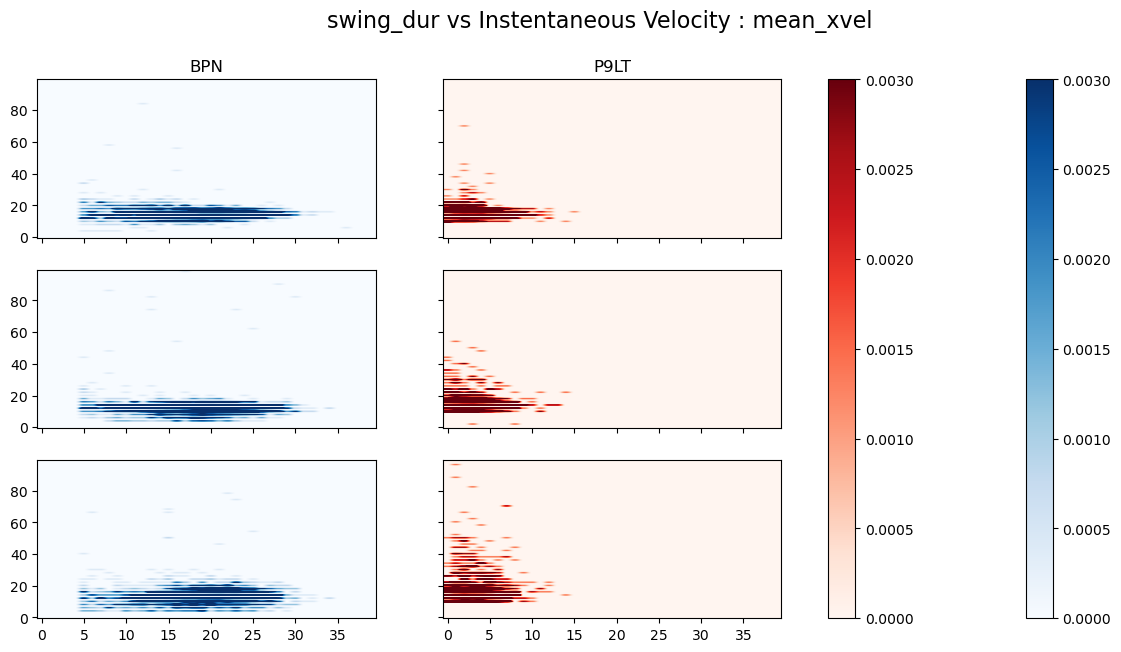

In [532]:
plot_velocity_dependence (All_data_dict_BPN, All_data_dict_P9LT, 'BPN', 'P9LT','swing_dur', 'mean_xvel', vel_min = 0, vel_max = 40, param_min = 0, param_max = 50)

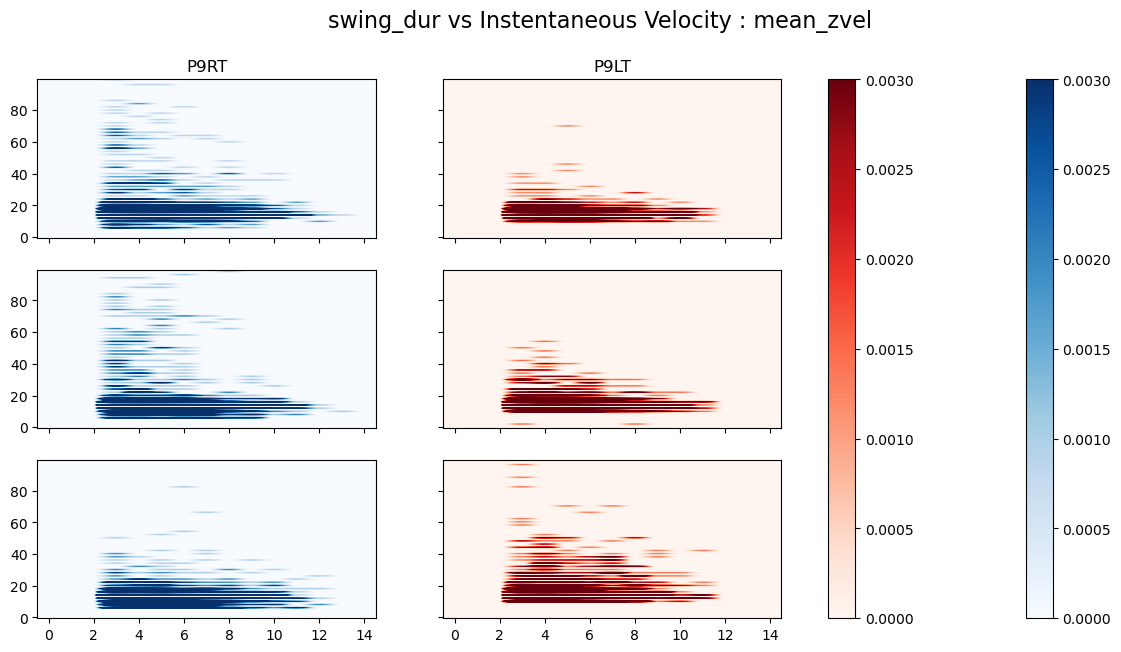

In [537]:
plot_velocity_dependence (All_data_dict_P9RT, All_data_dict_P9LT, 'P9RT', 'P9LT','swing_dur', 'mean_zvel', vel_min = 0, vel_max = 15, param_min = 0, param_max = 50)

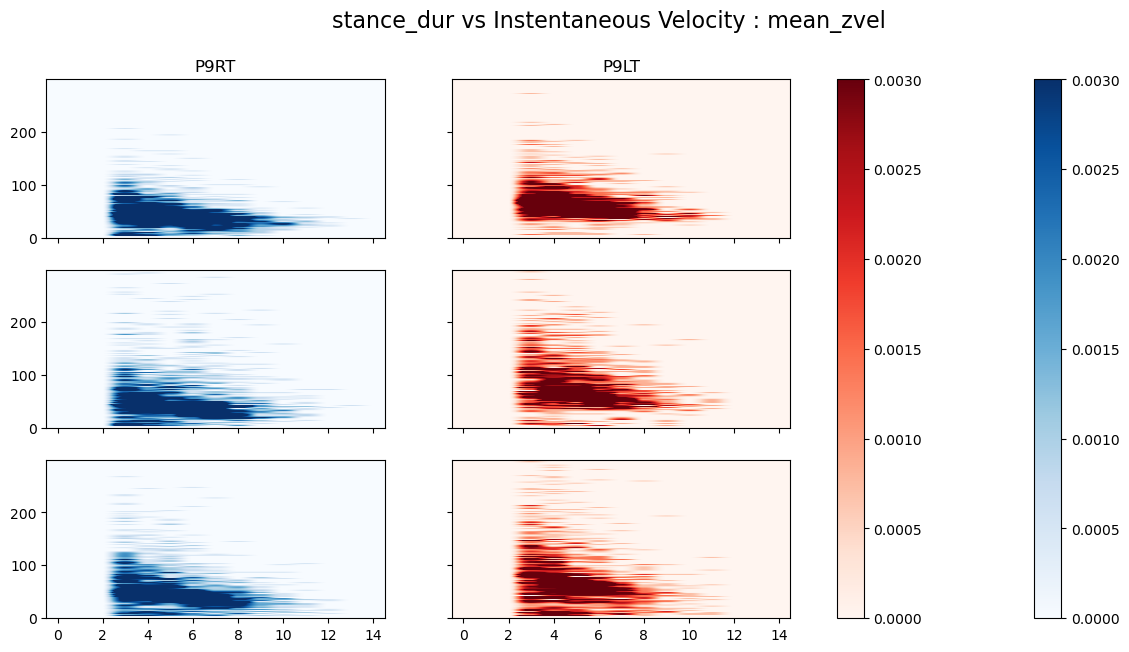

In [543]:
plot_velocity_dependence (All_data_dict_P9RT, All_data_dict_P9LT, 'P9RT', 'P9LT','stance_dur', 'mean_zvel', vel_min = 0, vel_max = 15, param_min = 0, param_max = 150)

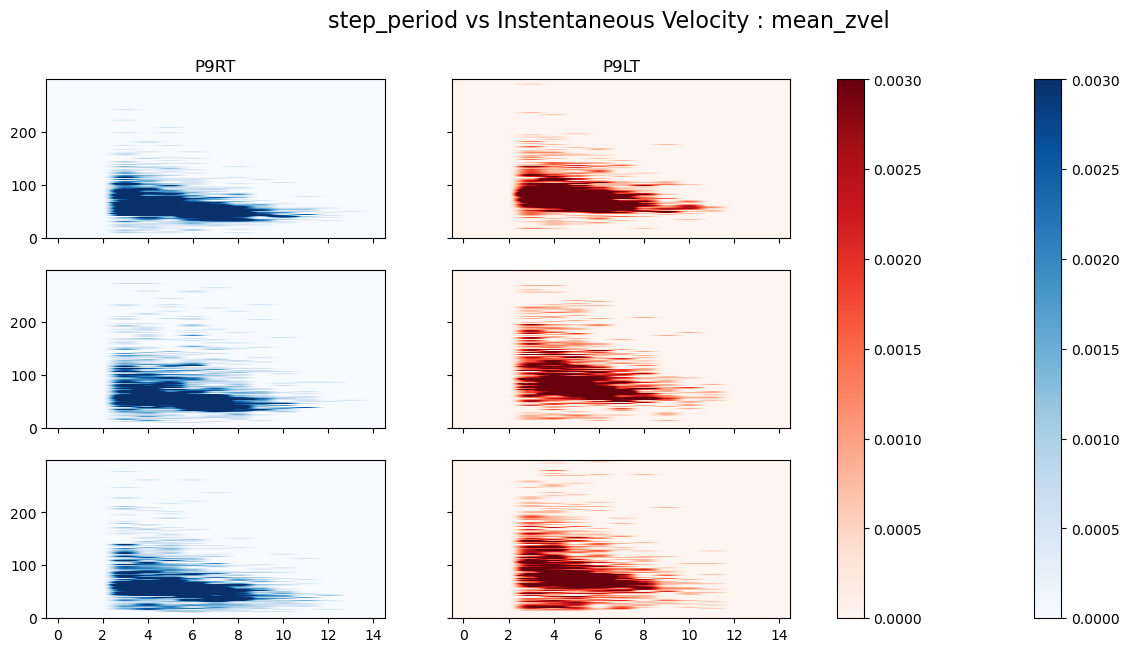

In [563]:
plot_velocity_dependence (All_data_dict_P9RT, All_data_dict_P9LT, 'P9RT', 'P9LT','step_period', 'mean_zvel', vel_min = 0, vel_max = 15, param_min = 0, param_max = 150)

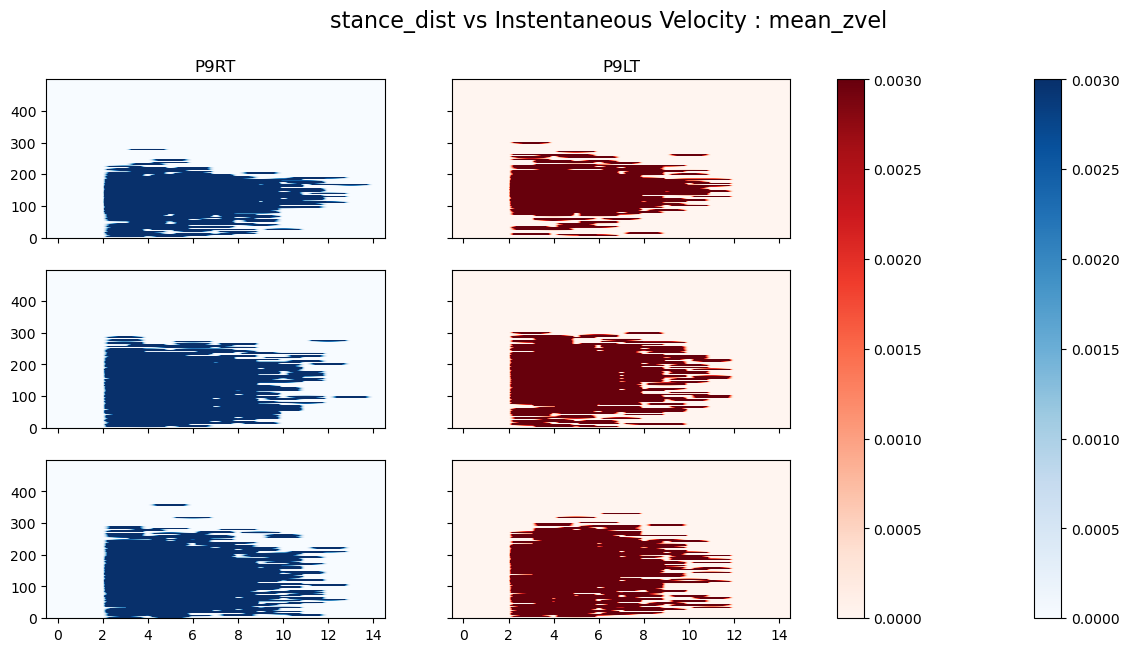

In [554]:
plot_velocity_dependence (All_data_dict_P9RT, All_data_dict_P9LT, 'P9RT', 'P9LT','stance_dist', 'mean_zvel', vel_min = 0, vel_max = 15, param_min = 0, param_max = 5)

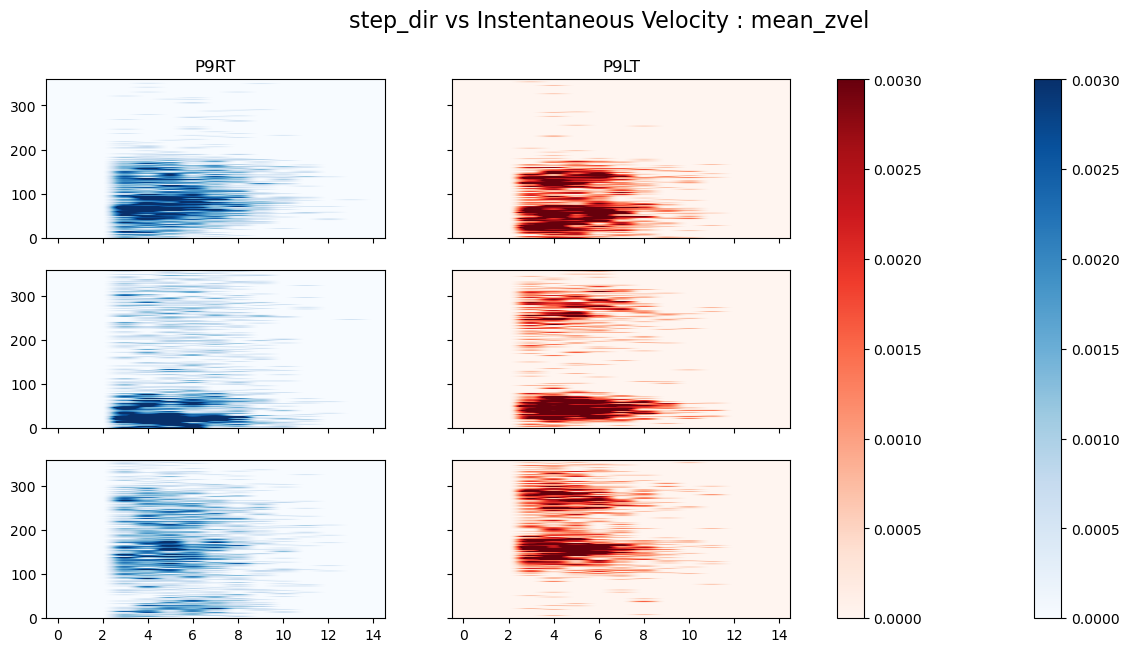

In [569]:
plot_velocity_dependence (All_data_dict_P9RT, All_data_dict_P9LT, 'P9RT', 'P9LT','step_dir', 'mean_zvel', vel_min = 0, vel_max = 15, param_min = 0, param_max = 180)